# 1. Multi-Armed Bandits — Your First Reinforcement Learning Problem

## What is Reinforcement Learning, really?

Forget the robots-and-video-games imagery for a second. At its core, **Reinforcement Learning (RL)** is a framework for learning good decisions *by trial and error*, from feedback, when you don't already know the right answer.

Every RL problem has the same ingredients:

| Concept | Meaning | Business analogy |
|---|---|---|
| **Agent** | The decision-maker | A pricing algorithm, a recommendation engine, a scheduler |
| **Action** | A choice the agent makes | Which price to charge, which ad to show, how much to order |
| **Reward** | Feedback signal after acting | Revenue, profit, conversion, cost saved |
| **Environment** | Everything the agent doesn't control | Customers, demand, competitors |
| **Policy** | The agent's strategy (state → action) | "If it's a loyal customer, offer 10% off" |

RL is different from the supervised learning you may already know (predict `y` from `X`) because **there is no labeled "correct answer"** — the agent only finds out how good its choice was *after* making it, and only for the action it actually took (not the ones it didn't try). That single fact — you only observe the outcome of what you did, never what would have happened otherwise — is the central challenge of RL, and it's what makes it a natural fit for sequential business decisions like pricing, targeting, and inventory control.

## The simplest possible RL problem: the Multi-Armed Bandit

Imagine you walk into a casino with 5 slot machines ("one-armed bandits"). Each machine pays out with some unknown, fixed probability/amount. You have a limited number of pulls. Which machine(s) do you play?

This is *the* classic starting point for RL because it strips away almost everything except the one core tension every RL agent must resolve:

> **Exploration vs. Exploitation** — do you keep pulling the arm that has paid off best so far (*exploit* what you know), or do you try a different arm to see if it's actually better (*explore* to learn more)?

This exact tension shows up constantly in business:
- Should we keep showing the ad creative that's converting well, or test new ones?
- Should we keep charging our best-known price, or experiment with new price points?
- Should we keep recommending what already works, or surface something new?

Note there's no "state" yet in this problem — every pull is the same situation. We'll add state (turning this into a full MDP) in the next notebook. Let's build it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
plt.rcParams['figure.figsize'] = (9, 4.5)

## Step 1 — Build the environment

We'll simulate 5 arms (think: 5 website designs, 5 ad creatives, 5 promo offers). Each arm pays out `1` (a "conversion" / "sale") with its own fixed but hidden probability. The agent doesn't know these probabilities — it has to learn them from experience.

In [2]:
N_ARMS = 5
true_conversion_rates = rng.uniform(0.05, 0.35, size=N_ARMS)
best_arm = np.argmax(true_conversion_rates)

print("True (hidden) conversion rate per arm:")
for i, p in enumerate(true_conversion_rates):
    marker = "  <- best" if i == best_arm else ""
    print(f"  Arm {i}: {p:.2%}{marker}")

def pull(arm):
    '''Simulate pulling an arm: returns reward 1 (success) or 0 (failure).'''
    return 1 if rng.random() < true_conversion_rates[arm] else 0

True (hidden) conversion rate per arm:
  Arm 0: 28.22%
  Arm 1: 18.17%
  Arm 2: 30.76%  <- best
  Arm 3: 25.92%
  Arm 4: 7.83%


## Step 2 — The naive baselines

Before building an RL agent, let's see how two naive strategies do:

1. **Pure random**: pick a random arm every time (no learning at all).
2. **Pure greedy**: try each arm once, then always exploit the one that looked best on that single try — no further exploration.

These are our baselines to beat.

In [12]:
N_STEPS = 2000

def run_random(n_steps=N_STEPS):
    rewards = np.zeros(n_steps)
    for t in range(n_steps):
        arm = rng.integers(N_ARMS) # pick a random arm
        rewards[t] = pull(arm)
    return rewards

def run_pure_greedy(n_steps=N_STEPS):
    rewards = np.zeros(n_steps)
    counts = np.zeros(N_ARMS)
    values = np.zeros(N_ARMS)
    for t in range(n_steps):
        if t < N_ARMS:
            arm = t  # try every arm once first
        else:
            arm = np.argmax(values) # once we have tried every arm, pick the one with the highest estimated value
        r = pull(arm)
        counts[arm] += 1
        # value update rule: new estimate = old estimate + (reward - old estimate) / number of times arm has been pulled
        # this is a simple way to compute the average reward for each arm incrementally
        values[arm] += (r - values[arm]) / counts[arm]
        #print(values)
        rewards[t] = r
    return rewards

random_rewards = run_random()
greedy_rewards = run_pure_greedy()

# the problem here is that depending on the random seed, the greedy strategy might not explore enough and 
# could get stuck on a suboptimal arm. This is a known issue with pure-greedy strategies.
print(f"Random strategy   average reward: {random_rewards.mean():.3f}")
print(f"Pure-greedy strategy average reward: {greedy_rewards.mean():.3f}")
print(f"Best possible (always pick best arm): {true_conversion_rates[best_arm]:.3f}")

Random strategy   average reward: 0.223
Pure-greedy strategy average reward: 0.302
Best possible (always pick best arm): 0.308


Notice pure-greedy often does only a little better than random — one lucky (or unlucky) early pull can permanently lock the agent into the wrong arm, because it never explores again. We need a strategy that balances exploration and exploitation *throughout*, not just at the start.

## Step 3 — Epsilon-greedy: a minimal RL agent

The **epsilon-greedy** algorithm is the simplest genuine RL strategy:

- With probability `epsilon` (e.g. 10%): **explore** — pick a random arm.
- Otherwise (probability `1 - epsilon`): **exploit** — pick the arm with the best estimated value so far.

After every pull, the agent updates its running estimate of that arm's value:

$$Q_{new}(a) = Q_{old}(a) + \alpha \cdot \big(r - Q_{old}(a)\big)$$

This is the **incremental update rule** you'll see again and again in RL: *nudge your current estimate toward the new observation*. `Q(a)` is the agent's current belief about how good action `a` is; `r` is the reward just observed; `alpha` is how fast it updates (here we just use the running average, i.e. `alpha = 1/count`). So the longer we have trained, the less effect the new update will have.

In [19]:
# A numercial example: Q_old = 1, r = 1, alpha = 0.1
# Then Q_new = 1 + 0.1 * (1 - 1) = 1 -> makes sense, because the reward was equal to the old estimate, so the new estimate should stay the same.
# Imagine in the next step we get a reward of 0, 
# then Q_new = 1 + 0.1 * (0 - 1) = 0.9 -> makes sense, because the reward was lower than the old estimate, so the new estimate should decrease.
# Alpha is the learning rate, which controls how much we update our estimate based on new information.
# A higher alpha means we trust new information more, while a lower alpha means we trust our old estimate more.

In [13]:
def run_epsilon_greedy(epsilon=0.1, n_steps=N_STEPS):
    rewards = np.zeros(n_steps)
    counts = np.zeros(N_ARMS)
    values = np.zeros(N_ARMS)   # Q(a) estimates
    for t in range(n_steps):
        if rng.random() < epsilon:
            arm = rng.integers(N_ARMS)          # explore (pick a random arm)
        else:
            arm = np.argmax(values)             # exploit (pick the best estimated arm)
        r = pull(arm)
        counts[arm] += 1
        values[arm] += (r - values[arm]) / counts[arm]   # incremental update
        rewards[t] = r
    return rewards, values, counts

eps_rewards, final_values, final_counts = run_epsilon_greedy(epsilon=0.1)

print(f"Epsilon-greedy (eps=0.1) average reward: {eps_rewards.mean():.3f}")
print("\nLearned value estimates vs. truth:")
for i in range(N_ARMS):
    print(f"  Arm {i}: estimated={final_values[i]:.3f}  true={true_conversion_rates[i]:.3f}  pulls={int(final_counts[i])}")

Epsilon-greedy (eps=0.1) average reward: 0.263

Learned value estimates vs. truth:
  Arm 0: estimated=0.270  true=0.282  pulls=1687
  Arm 1: estimated=0.079  true=0.182  pulls=38
  Arm 2: estimated=0.309  true=0.308  pulls=181
  Arm 3: estimated=0.167  true=0.259  pulls=42
  Arm 4: estimated=0.077  true=0.078  pulls=52


Notice the agent naturally pulls the best arm far more often, but still keeps a trickle of exploration going to the others — and its value estimates converge close to the true probabilities.

## Step 4 — Compare strategies over time (cumulative regret)

The standard way to judge a bandit algorithm isn't just "final average reward" — it's **cumulative regret**: the total reward you *lost* by not always playing the best arm from the very first step. A flattening regret curve means the agent has converged on the best action; a straight line means it's still making costly mistakes.

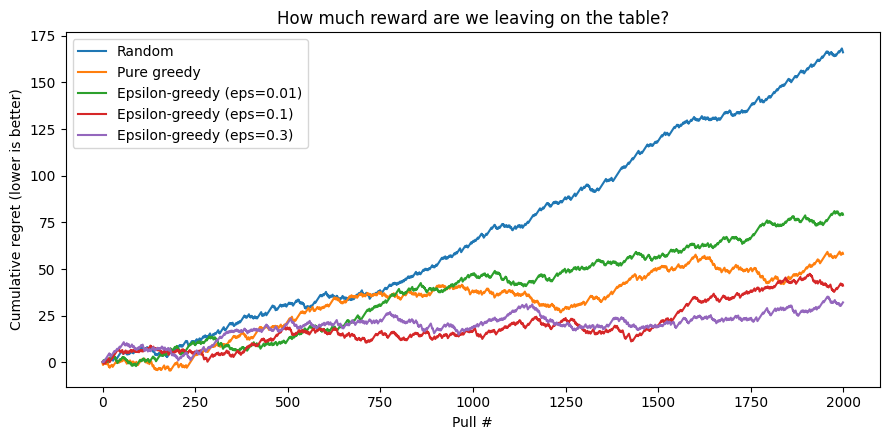

In [17]:
def cumulative_regret(rewards):
    best_possible = true_conversion_rates[best_arm] * np.arange(1, len(rewards) + 1)
    return best_possible - np.cumsum(rewards)

strategies = {
    "Random": run_random(),
    "Pure greedy": run_pure_greedy(),
    "Epsilon-greedy (eps=0.01)": run_epsilon_greedy(epsilon=0.01)[0],
    "Epsilon-greedy (eps=0.1)": run_epsilon_greedy(epsilon=0.1)[0],
    "Epsilon-greedy (eps=0.3)": run_epsilon_greedy(epsilon=0.3)[0],
}

plt.figure()
for name, rewards in strategies.items():
    plt.plot(cumulative_regret(rewards), label=name)
plt.xlabel("Pull #")
plt.ylabel("Cumulative regret (lower is better)")
plt.title("How much reward are we leaving on the table?")
plt.legend()
plt.tight_layout()
plt.show()

A few things to notice in the plot:

- **Random** regret grows in a straight line forever — it never learns.
- **Pure greedy** can plateau early, but at a *worse* level, because it commits before it has enough evidence (it got unlucky/lucky on the first try and never revisits that decision).
- **Epsilon-greedy** curves bend and flatten as the agent learns which arm is best — the flatter the curve gets, the more confident/correct the policy has become.
- Too little exploration (`eps=0.01`) learns slowly at the start; too much exploration (`eps=0.3`) keeps paying an exploration "tax" forever by trying obviously-bad arms too often. This is the exploration/exploitation tradeoff in action, and tuning it is a real design decision in production systems.

## Key takeaways

1. RL agents learn a **policy** (what to do) purely from **reward feedback**, without labeled "correct" examples.
2. The **exploration vs. exploitation tradeoff** is the central challenge — and epsilon-greedy is the simplest way to manage it.
3. Agents maintain **value estimates** `Q(a)` and update them incrementally as new evidence arrives.
4. We measure performance with **cumulative regret**, not just accuracy — how much reward did we lose while learning?

**What's missing from this problem?** Every decision here was identical — there was no notion of *state* (context that changes over time and affects which action is best). Real business problems almost always have state: how much inventory is left, what time of day it is, which customer segment you're looking at. That's exactly what we add next, in the **Gridworld** notebook, which introduces the full Markov Decision Process (MDP) framework and Q-learning.

*(Side note: multi-armed bandits **with** context — "contextual bandits" — are themselves hugely used in industry for offer/ad targeting. We come back to that in notebook 5.)*